In [3]:
print("hgsh")

hgsh


Data Parsing

In [10]:
#!/usr/bin/env python
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
# logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

SOURCE = Path("../data/ABB 800xA User Manual.pdf")
OUTPUT_DIR = Path("parsed-doc-advanced1")
IMAGE_RESOLUTION_SCALE = 2.0

from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc import ImageRefMode
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode

# Try to pick an available OCR backend option
ocr_opts = None
try:
    from docling.datamodel.pipeline_options import RapidOcrOptions
    ocr_opts = RapidOcrOptions(force_full_page_ocr=True)
except Exception:
    try:
        from docling.datamodel.pipeline_options import EasyOcrOptions
        ocr_opts = EasyOcrOptions(force_full_page_ocr=True)
    except Exception:
        try:
            from docling.datamodel.pipeline_options import TesseractOcrOptions
            ocr_opts = TesseractOcrOptions(force_full_page_ocr=True)
        except Exception:
            print("No OCR backend available. OCR will be disabled.")
            ocr_opts = None

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,
    # Disable OCR here to avoid heavy ONNX models on limited environments.
    # ocr_options=RapidOcrOptions(force_full_page_ocr=True, lang=["en"]),
    # table_structure_options=dict(
    #     do_cell_matching=False,  # Use text cells predicted from table structure model
    #     mode=TableFormerMode.ACCURATE  # Use more accurate TableFormer model
    # ),
    do_ocr=False,
    generate_page_images=True,
    generate_picture_images=True,
    generate_parsed_pages=True,
    images_scale=IMAGE_RESOLUTION_SCALE,
)

conv = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not SOURCE.exists():
    print("SOURCE PDF not found:", SOURCE)
    raise SystemExit(2)

print('Starting conversion...')
result = conv.convert(SOURCE)
md = OUTPUT_DIR / f"{SOURCE.stem}-with-images.md"
result.document.save_as_markdown(md, image_mode=ImageRefMode.EMBEDDED)
print('SAVED', md)


Starting conversion...


Loading weights: 100%|██████████| 770/770 [00:00<00:00, 5798.66it/s]


SAVED parsed-doc-advanced1\ABB 800xA User Manual-with-images.md


## Chunking

In [5]:
#!/usr/bin/env python3
"""
convert_md_with_base64_images.py

Reads a Markdown file containing inline base64 images and/or image placeholders,
extracts all images, chunks the document (using docling if available, otherwise a fallback),
maps images back to chunks using placeholder-aware heuristics, writes a JSONL of chunks,
and optionally writes extracted images to disk for verification.

Edit MD_PATH and OUT_DIR at the top as needed, then run:
    python convert_md_with_base64_images.py
"""

from pathlib import Path
import re
import json
import unicodedata
import base64
from collections import deque
import sys

# -------------------------
# Configuration - edit these
# -------------------------
MD_PATH = Path("parsed-doc-advanced1") / "ABB 800xA User Manual-with-images.md"
OUT_DIR = Path("../data/processed")
STEM = "relay_manual"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / f"{STEM}.chunks.jsonl"
IMAGES_OUT_DIR = OUT_DIR / "images"
IMAGES_OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Optional: Docling / Transformers
# -------------------------
try:
    from transformers import AutoTokenizer
    from docling.chunking import HybridChunker
    from docling.document_converter import DocumentConverter
    from docling.datamodel.base_models import InputFormat

    DOCILING_AVAILABLE = True
except Exception:
    DOCILING_AVAILABLE = False

# -------------------------
# Regex patterns
# -------------------------
# Match inline base64 images: ![alt](data:image/png;base64,AAAA...)
IMAGE_PATTERN = re.compile(
    r'!\[(.*?)\]\(data:image/(?P<fmt>[A-Za-z0-9_+\-]+);base64,(?P<data>[A-Za-z0-9+/=_\-\n\r]+)\)',
    re.DOTALL,
)

# Placeholders: HTML comment <!-- image -->, literal "Image" on its own line, or inline image syntax
PLACEHOLDER_PATTERN = re.compile(
    r'<!--\s*image\s*-->|^\s*Image\s*$|!\[.*?\]\(data:image/.*?\)',
    re.IGNORECASE | re.MULTILINE | re.DOTALL,
)

FIGURE_PATTERN = re.compile(r'Figure\s+(\d+)\.\s*(.+)', re.IGNORECASE | re.MULTILINE)
TABLE_PATTERN = re.compile(r'(Table\s+\d+\..*?(?:\n\|.*)+)', re.DOTALL | re.IGNORECASE)
BULLET_PATTERN = re.compile(r'^\s*-\s+(.*)', re.MULTILINE)

# -------------------------
# Utilities
# -------------------------
def clean(text: str) -> str:
    if not text:
        return text
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)
    text = re.sub(r"\n[ \t]*Page\s+\d+.*?(?=\n)", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def fallback_chunk_text(md_text):
    """
    Simple fallback chunker: split by two or more newlines into blocks.
    Returns list of simple Chunk objects with .text and .meta.headings/.meta.doc_items.
    """
    blocks = [b.strip() for b in re.split(r"\n\s*\n", md_text) if b.strip()]

    class Chunk:
        def __init__(self, text):
            self.text = text
            self.meta = type("M", (), {})()
            self.meta.headings = []
            self.meta.doc_items = []

    return [Chunk(b) for b in blocks]

def extract_figures(text):
    figures = []
    for m in FIGURE_PATTERN.finditer(text):
        figures.append({"figure_number": int(m.group(1)), "caption": m.group(2).strip()})
    return figures

def extract_tables(text):
    tables = []
    for m in TABLE_PATTERN.finditer(text):
        block = m.group(1).strip()
        first_line = block.splitlines()[0]
        tables.append({"title": first_line, "markdown": block})
    return tables

def extract_bullets(text):
    return BULLET_PATTERN.findall(text)

# -------------------------
# Read raw markdown and extract all base64 images (in order)
# -------------------------
if not MD_PATH.exists():
    print(f"Error: MD file not found at {MD_PATH}", file=sys.stderr)
    sys.exit(1)

RAW_MD = MD_PATH.read_text(encoding="utf-8")

ALL_IMAGES = []
for i, m in enumerate(IMAGE_PATTERN.finditer(RAW_MD), start=1):
    b64 = m.group("data").replace("\n", "").replace("\r", "")
    ALL_IMAGES.append({
        "image_id": f"img_{i:05d}",
        "format": m.group("fmt"),
        "base64": b64,
        "placeholder_span": (m.start(), m.end()),
    })

print(f"Images found in markdown: {len(ALL_IMAGES)}")

PLACEHOLDERS = [m.span() for m in PLACEHOLDER_PATTERN.finditer(RAW_MD)]
print(f"Placeholders found in markdown: {len(PLACEHOLDERS)}")

# -------------------------
# Convert and chunk document (Docling if available, else fallback)
# -------------------------
chunks = []
if DOCILING_AVAILABLE:
    try:
        print("Using Docling to convert and chunk the markdown...")
        converter = DocumentConverter(allowed_formats=[InputFormat.MD])
        result = converter.convert(str(MD_PATH))
        doc = result.document

        # Try to use HybridChunker if tokenizer available
        try:
            tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
        except Exception:
            tokenizer = None

        if tokenizer is not None:
            chunker = HybridChunker(tokenizer=tokenizer, max_tokens=768, merge_peers=True)
            chunks = list(chunker.chunk(dl_doc=doc))
        else:
            exported = doc.export_to_markdown()
            chunks = fallback_chunk_text(exported)
    except Exception as e:
        print("Docling conversion failed, falling back to simple chunking. Error:", e)
        chunks = fallback_chunk_text(RAW_MD)
else:
    print("Docling not available; using fallback chunking on RAW_MD.")
    chunks = fallback_chunk_text(RAW_MD)

print("Total chunks:", len(chunks))

# -------------------------
# Mapping placeholders to images and building records
# -------------------------
all_images_deque = deque(ALL_IMAGES)  # FIFO

def chunk_contains_placeholder(chunk_text):
    return bool(PLACEHOLDER_PATTERN.search(chunk_text))

def attach_images_to_chunk_by_placeholder(chunk_text, images_deque):
    """
    Attach as many images as there are placeholders in the chunk_text (FIFO from images_deque).
    """
    imgs = []
    matches = PLACEHOLDER_PATTERN.findall(chunk_text)
    for _ in matches:
        if images_deque:
            imgs.append(images_deque.popleft())
    return imgs

def should_attach_by_heuristic(chunk_text):
    """
    Heuristic: attach an image if chunk is empty/very short or equals 'Image' or only contains an HTML comment.
    """
    t = chunk_text.strip()
    if not t:
        return True
    if t.lower() == "image":
        return True
    # If chunk is short and contains no letters beyond 'Image' placeholder
    if len(t) <= 12 and re.match(r'^[^A-Za-z0-9]*$', re.sub(r'Image', '', t, flags=re.IGNORECASE)):
        return True
    return False

records = []

for idx, chunk in enumerate(chunks):
    # chunk may be a simple object or a docling chunk; handle both
    raw_text = ""
    if hasattr(chunk, "text"):
        raw_text = clean(chunk.text or "")
    else:
        raw_text = clean(str(chunk))

    text_without_images = raw_text
    images_attached = []

    # 1) If chunk contains explicit placeholders, attach corresponding images
    if chunk_contains_placeholder(raw_text) and all_images_deque:
        images_attached.extend(attach_images_to_chunk_by_placeholder(raw_text, all_images_deque))

    # 2) If no placeholders but chunk is a short/empty block, attach next image (heuristic)
    if not images_attached and should_attach_by_heuristic(raw_text) and all_images_deque:
        images_attached.append(all_images_deque.popleft())

    # 3) If chunk text contains inline base64 (rare because docling may strip), extract them
    inline_images = []
    for m in IMAGE_PATTERN.finditer(raw_text):
        inline_images.append({
            "format": m.group("fmt"),
            "base64": m.group("data").replace("\n", "").replace("\r", ""),
        })
    if inline_images:
        images_attached.extend(inline_images)

    # Build embed_text (simple fallback: use chunk text)
    embed_text = text_without_images

    # headings and doc_items if present
    headings = []
    try:
        headings = list(getattr(chunk.meta, "headings", None) or [])
    except Exception:
        headings = []

    # element type detection (simple)
    labels = set()
    try:
        labels = {str(getattr(it, "label", "")).lower() for it in (getattr(chunk.meta, "doc_items", None) or [])}
    except Exception:
        labels = set()

    if any("table" in l for l in labels):
        etype = "table"
    elif any("formula" in l or "equation" in l for l in labels):
        etype = "formula"
    elif any("picture" in l or "figure" in l for l in labels):
        etype = "figure"
    else:
        etype = "text"

    figures = extract_figures(raw_text)
    tables = extract_tables(raw_text)
    bullets = extract_bullets(raw_text)

    record = {
        "chunk_id": f"{STEM}_c{idx+1:04d}",
        "source_pdf": f"{STEM}.pdf",
        "page": None,
        "section": headings[-1] if headings else None,
        "headings": headings,
        "element_type": etype,
        "table_flag": len(tables) > 0,
        "figure_flag": len(figures) > 0,
        "formula_flag": etype == "formula",
        "text": text_without_images,
        "embed_text": embed_text,
        "images": images_attached,
        "figures": figures,
        "tables": tables,
        "bullets": bullets,
    }
    records.append(record)

# -------------------------
# Write JSONL
# -------------------------
with OUT_PATH.open("w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Chunks written:", OUT_PATH)

# -------------------------
# Optionally write out attached images to files for verification
# -------------------------
written = 0
with OUT_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        for img in rec.get("images", []):
            iid = img.get("image_id") or f"img_auto_{written+1:05d}"
            fmt = img.get("format", "png")
            b64 = img.get("base64")
            if not b64:
                continue
            out_path = IMAGES_OUT_DIR / f"{iid}.{fmt}"
            try:
                out_path.write_bytes(base64.b64decode(b64))
                written += 1
            except Exception:
                # skip invalid base64
                pass

print(f"Wrote {written} image files to {IMAGES_OUT_DIR}")

# -------------------------
# Verification counts
# -------------------------
attached_count = 0
with OUT_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        attached_count += len(rec.get("images", []))

print(f"Images extracted from RAW_MD: {len(ALL_IMAGES)}")
print(f"Images attached into JSONL: {attached_count}")
print(f"Images remaining in deque (not attached): {len(all_images_deque)}")

if attached_count != len(ALL_IMAGES):
    print("Warning: counts differ. Consider using a placeholder-offset mapping approach if many images remain unattached.")
else:
    print("Success: all images attached to chunks.")

Images found in markdown: 386
Placeholders found in markdown: 386
Using Docling to convert and chunk the markdown...
Total chunks: 321
Chunks written: ..\data\processed\relay_manual.chunks.jsonl
Wrote 386 image files to ..\data\processed\images
Images extracted from RAW_MD: 386
Images attached into JSONL: 386
Images remaining in deque (not attached): 0
Success: all images attached to chunks.


In [38]:
#!/usr/bin/env python
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
# logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

SOURCE = Path("../data/ABB 800xA User Manual.pdf")
OUTPUT_DIR = Path("parsed-doc-advanced1")
IMAGE_RESOLUTION_SCALE = 2.0

from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc import ImageRefMode
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode

# Try to pick an available OCR backend option
ocr_opts = None
try:
    from docling.datamodel.pipeline_options import RapidOcrOptions
    ocr_opts = RapidOcrOptions(force_full_page_ocr=True)
except Exception:
    try:
        from docling.datamodel.pipeline_options import EasyOcrOptions
        ocr_opts = EasyOcrOptions(force_full_page_ocr=True)
    except Exception:
        try:
            from docling.datamodel.pipeline_options import TesseractOcrOptions
            ocr_opts = TesseractOcrOptions(force_full_page_ocr=True)
        except Exception:
            print("No OCR backend available. OCR will be disabled.")
            ocr_opts = None

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,
    do_ocr=True if ocr_opts is not None else False,

    generate_page_images=True,
    generate_picture_images=True,
    
    images_scale=IMAGE_RESOLUTION_SCALE,
)

conv = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not SOURCE.exists():
    print("SOURCE PDF not found:", SOURCE)
    raise SystemExit(2)

print('Starting conversion...')
result = conv.convert(SOURCE)
md = OUTPUT_DIR / f"{SOURCE.stem}-with-images.md"
result.document.save_as_markdown(md, image_mode=ImageRefMode.EMBEDDED)
print('SAVED', md)


2026-07-12 02:20:54,149 INFO: detected formats: [<InputFormat.PDF: 'pdf'>]
2026-07-12 02:20:54,167 INFO: Going to convert document batch...
2026-07-12 02:20:54,168 INFO: Initializing pipeline for StandardPdfPipeline with options hash df5ee1c378c8f0acb1817150103a25ec
2026-07-12 02:20:54,169 INFO: Accelerator device: 'cpu'


[INFO] 2026-07-12 02:20:54,187 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 02:20:54,194 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 02:20:54,195 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 02:20:54,257 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 02:20:54,259 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 02:20:54,260 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 02:20:54,315 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 02:20:54,332 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\ra

Starting conversion...


2026-07-12 02:20:54,429 INFO: Auto OCR model selected rapidocr with onnxruntime.
2026-07-12 02:20:54,429 INFO: Accelerator device: 'cpu'
2026-07-12 02:20:54,692 INFO: HTTP Request: GET https://huggingface.co/api/models/docling-project/docling-layout-heron/revision/main "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 9868.53it/s]
2026-07-12 02:20:55,200 INFO: HTTP Request: GET https://huggingface.co/api/models/docling-project/docling-models/revision/v2.3.0 "HTTP/1.1 200 OK"
2026-07-12 02:20:55,209 INFO: Accelerator device: 'cpu'
2026-07-12 02:20:55,669 INFO: Processing document ABB 800xA User Manual.pdf
2026-07-12 02:21:20,923 WARNING: RapidOCR returned empty result!
2026-07-12 02:21:39,924 WARNING: RapidOCR returned empty result!
2026-07-12 02:21:40,521 WARNING: RapidOCR returned empty result!
2026-07-12 02:21:48,802 WARNING: RapidOCR returned empty result!
2026-07-12 02:21:54,393 WARNING: RapidOCR returned empty result!
2026-07-12 02:21:55,774 WARNING: RapidO

SAVED parsed-doc-advanced1\ABB 800xA User Manual-with-images.md


##  JSON Format


In [3]:
import json
import re
import unicodedata
from pathlib import Path

from transformers import AutoTokenizer
from docling.chunking import HybridChunker
from docling.document_converter import DocumentConverter
from docling.datamodel.base_models import InputFormat

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

STEM = "relay_manual"

MD_PATH = Path("parsed-doc-advanced1") / "ABB 800xA User Manual-with-images.md"
# Read original markdown before Docling conversion
RAW_MD = MD_PATH.read_text(encoding="utf-8")
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / f"{STEM}.chunks.jsonl"

EMBED_MODEL = "BAAI/bge-m3"
MAX_TOKENS = 768
MERGE_PEERS = True

# ------------------------------------------------------------------
# Regex Patterns
# ------------------------------------------------------------------

IMAGE_PATTERN = re.compile(
    r'!\[(.*?)\]\(data:image/(?P<fmt>\w+);base64,(?P<data>[A-Za-z0-9+/=\n\r=]+)\)',
    re.DOTALL,
)

FIGURE_PATTERN = re.compile(
    r'Figure\s+(\d+)\.\s*(.+)',
    re.IGNORECASE | re.MULTILINE,
)

TABLE_PATTERN = re.compile(
    r'(Table\s+\d+\..*?(?:\n\|.*)+)',
    re.DOTALL | re.IGNORECASE,
)

BULLET_PATTERN = re.compile(
    r'^\s*-\s+(.*)',
    re.MULTILINE,
)

# Extract all images before Docling removes them
ALL_IMAGES = []

for i, m in enumerate(IMAGE_PATTERN.finditer(RAW_MD), start=1):
    ALL_IMAGES.append({
        "image_id": f"img_{i:05d}",
        "format": m.group("fmt"),
        "base64": m.group("data").replace("\n", "")
    })

print(f"Images found in markdown: {len(ALL_IMAGES)}")


# ------------------------------------------------------------------
# Text Cleaning
# ------------------------------------------------------------------

def clean(text: str) -> str:
    if not text:
        return text

    text = unicodedata.normalize("NFKC", text)

    # De-hyphenate words split across lines
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)

    # Remove page footer
    text = re.sub(r"\n[ \t]*Page\s+\d+.*?(?=\n)", "\n", text)

    # Collapse spaces/tabs
    text = re.sub(r"[ \t]+", " ", text)

    return text.strip()


# ------------------------------------------------------------------
# Read Markdown
# ------------------------------------------------------------------

print("Reading Markdown:", MD_PATH)

converter = DocumentConverter(
    allowed_formats=[InputFormat.MD]
)

result = converter.convert(str(MD_PATH))

doc = result.document
print("\nFirst 300 characters of Docling Markdown:")
print(doc.export_to_markdown()[:300])
print("Loaded document from .md")


# ------------------------------------------------------------------
# Chunking
# ------------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL)

chunker = HybridChunker(
    tokenizer=tokenizer,
    max_tokens=MAX_TOKENS,
    merge_peers=MERGE_PEERS,
)

chunks = list(chunker.chunk(dl_doc=doc))

print("Total chunks:", len(chunks))


# ------------------------------------------------------------------
# Element Type Detection
# ------------------------------------------------------------------

def element_type(chunk):
    labels = {
        str(getattr(it, "label", "")).lower()
        for it in (chunk.meta.doc_items or [])
    }

    if any("table" in l for l in labels):
        return "table"

    if any("formula" in l or "equation" in l for l in labels):
        return "formula"

    if any("picture" in l or "figure" in l for l in labels):
        return "figure"

    return "text"

def extract_images(text):
    images = []

    for m in IMAGE_PATTERN.finditer(text):
        images.append(
            {
                "format": m.group("fmt"),
                "base64": m.group("data").replace("\n", ""),
            }
        )

    cleaned = IMAGE_PATTERN.sub("", text)

    return cleaned, images


def extract_figures(text):
    figures = []

    for m in FIGURE_PATTERN.finditer(text):
        figures.append(
            {
                "figure_number": int(m.group(1)),
                "caption": m.group(2).strip(),
            }
        )

    return figures


def extract_tables(text):
    tables = []

    for m in TABLE_PATTERN.finditer(text):
        block = m.group(1).strip()

        first_line = block.splitlines()[0]

        tables.append(
            {
                "title": first_line,
                "markdown": block,
            }
        )

    return tables


def extract_bullets(text):
    return BULLET_PATTERN.findall(text)

# ------------------------------------------------------------------
# Write JSONL
# ------------------------------------------------------------------

with OUT_PATH.open(mode="w", encoding="utf-8") as f:

    for idx, chunk in enumerate(chunks):

        raw_text = clean(chunk.text)

        # Docling has already removed Base64 images.
        text_without_images = raw_text
        images = []

        # Detect figures
        figures = extract_figures(text_without_images)

        # Detect tables
        tables = extract_tables(text_without_images)

        # Detect bullet lists
        bullets = extract_bullets(text_without_images)

        # Build embedding text (without Base64)
        context_text = clean(
            chunker.contextualize(chunk=chunk)
            )

        context_text, _ = extract_images(context_text)

        headings = list(
            getattr(chunk.meta, "headings", None) or []
        )

        etype = element_type(chunk)

        # If the chunk only contains "Image", attach the next image
        if text_without_images.strip() == "Image" and ALL_IMAGES:
            images.append(ALL_IMAGES.pop(0))

        record = {
            "chunk_id": f"{STEM}_c{idx+1:04d}",
            "source_pdf": f"{STEM}.pdf",
            "page": None,
            "section": headings[-1] if headings else None,
            "headings": headings,
            "element_type": etype,

            "table_flag": len(tables) > 0,
            "figure_flag": len(figures) > 0,
            "formula_flag": etype == "formula",

            "text": text_without_images,

            "embed_text": context_text,

            "images": images,

            "figures": figures,

            "tables": tables,

            "bullets": bullets,
        }

        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Chunks written:", OUT_PATH)


# ------------------------------------------------------------------
# Preview
# ------------------------------------------------------------------

for c in chunks[:3]:

    print("-" * 60)

    print(
        "section:",
        (list(getattr(c.meta, "headings", None) or []) or [None])[-1],
    )

    print("type:", element_type(c))

    print(
        "preview:",
        clean(c.text)[:160].replace("\n", " "),
    )

Images found in markdown: 386
Reading Markdown: parsed-doc-advanced1\ABB 800xA User Manual-with-images.md

First 300 characters of Docling Markdown:
<!-- image -->

Image

## System 800xA Operations

Power and productivity for a better world TM

System Version 5.1

<!-- image -->

Image

## System 800xA Operations

System Version 5.1

## NOTICE

This document contains information about one or more ABB products and may include a description of or
Loaded document from .md
Total chunks: 321
Chunks written: ..\data\processed\relay_manual.chunks.jsonl
------------------------------------------------------------
section: None
type: text
preview: Image
------------------------------------------------------------
section: System 800xA Operations
type: text
preview: Power and productivity for a better world TM System Version 5.1 Image System Version 5.1
------------------------------------------------------------
section: NOTICE
type: text
preview: This document contains information about one o

In [43]:
#!/usr/bin/env python
import logging
import warnings
import base64
import json
from pathlib import Path

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

SOURCE = Path("../data/ABB 800xA User Manual.pdf")
OUTPUT_DIR = Path("parsed-doc-advanced1")
IMAGE_RESOLUTION_SCALE = 2.0

# Choose "embed" to include images as base64 in JSON, or "files" to write image files and reference paths
IMAGE_OUTPUT_MODE = "embed"  # or "files"

from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc import ImageRefMode
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode

# Defensive import for concrete table options (workaround for factory KeyError/AttributeError)
try:
    from docling.datamodel.pipeline_options import TableStructureOptions
    concrete_table_opts = TableStructureOptions()
except Exception:
    concrete_table_opts = None

# Try to pick an available OCR backend option
ocr_opts = None
try:
    from docling.datamodel.pipeline_options import RapidOcrOptions
    ocr_opts = RapidOcrOptions(force_full_page_ocr=True)
except Exception:
    try:
        from docling.datamodel.pipeline_options import EasyOcrOptions
        ocr_opts = EasyOcrOptions(force_full_page_ocr=True)
    except Exception:
        try:
            from docling.datamodel.pipeline_options import TesseractOcrOptions
            ocr_opts = TesseractOcrOptions(force_full_page_ocr=True)
        except Exception:
            logging.info("No OCR backend available. OCR will be disabled.")
            ocr_opts = None

# Build pipeline options; attach a concrete table options instance if available
pipeline_options = PdfPipelineOptions(
    do_table_structure=True,
    do_ocr=False,
    generate_page_images=True,
    generate_picture_images=True,
    images_scale=IMAGE_RESOLUTION_SCALE,
)

if concrete_table_opts is not None:
    # attach the concrete instance to avoid factory instantiation issues
    pipeline_options.table_structure_options = concrete_table_opts

conv = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not SOURCE.exists():
    logging.error("SOURCE PDF not found: %s", SOURCE)
    raise SystemExit(2)

logging.info("Starting conversion...")
result = conv.convert(SOURCE)

# Convert the document model to a serializable dict
# Use pydantic .dict() to get a JSON-serializable structure
doc_model = result.document
doc_dict = doc_model.dict(by_alias=True, exclude_none=True)

# Helper: extract and write images if requested
def _save_images_and_update_refs(doc_dict, out_dir: Path):
    """
    Walks doc_dict for image refs and either embeds base64 or writes files and updates refs.
    This assumes image entries are under predictable keys like 'images' or page-level image refs.
    Adjust the key paths if your doc model differs.
    """
    images_dir = out_dir / "images"
    images_dir.mkdir(parents=True, exist_ok=True)

    # Example traversal: look for dicts that contain 'image_ref' or 'image' keys
    # This is conservative; adapt to your doc model structure if needed.
    def _process_node(node):
        if isinstance(node, dict):
            # common key names: 'image', 'image_ref', 'image_bytes', 'ref'
            for k, v in list(node.items()):
                if isinstance(v, dict):
                    _process_node(v)
                elif isinstance(v, list):
                    for item in v:
                        _process_node(item)
                else:
                    # If the model stores raw bytes under a key like 'image_bytes', handle it
                    if k in ("image_bytes", "image_data") and isinstance(v, (bytes, bytearray)):
                        if IMAGE_OUTPUT_MODE == "embed":
                            node["image_base64"] = base64.b64encode(v).decode("ascii")
                            del node[k]
                        else:
                            # write file
                            fname = f"img_{len(list(images_dir.iterdir())) + 1}.bin"
                            fpath = images_dir / fname
                            with open(fpath, "wb") as fh:
                                fh.write(v)
                            node["image_path"] = str(fpath)
                            del node[k]
                    # If the model stores an ImageRef object with a 'data' or 'bytes' field
                    if k in ("image_ref", "image") and isinstance(v, dict):
                        # try to find embedded bytes inside
                        if "bytes" in v and isinstance(v["bytes"], (bytes, bytearray)):
                            b = v["bytes"]
                            if IMAGE_OUTPUT_MODE == "embed":
                                node[k]["base64"] = base64.b64encode(b).decode("ascii")
                                del node[k]["bytes"]
                            else:
                                fname = f"img_{len(list(images_dir.iterdir())) + 1}.png"
                                fpath = images_dir / fname
                                with open(fpath, "wb") as fh:
                                    fh.write(b)
                                node[k]["path"] = str(fpath)
                                del node[k]["bytes"]
        elif isinstance(node, list):
            for item in node:
                _process_node(item)

    _process_node(doc_dict)

# If you know where images are stored in the model, you can call the helper to embed or save them.
# If your doc model already stores image references as file paths or URLs, you can skip this.
try:
    _save_images_and_update_refs(doc_dict, OUTPUT_DIR)
except Exception as e:
    logging.warning("Image extraction/update step failed: %s", e)

# Write JSON file
# json_path = OUTPUT_DIR / f"{SOURCE.stem}.json"
# with open(json_path, "w", encoding="utf-8") as f:
#     json.dump(doc_dict, f, ensure_ascii=False, indent=2)

# logging.info("Saved parsed JSON to %s", json_path)

from pydantic.json import pydantic_encoder
import json

doc_dict = result.document.dict(by_alias=True, exclude_none=True)
json_path = OUTPUT_DIR / f"{SOURCE.stem}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(doc_dict, f, ensure_ascii=False, indent=2, default=pydantic_encoder)
logging.info("Saved parsed JSON to %s", json_path)

2026-07-12 03:12:08,290 INFO: Starting conversion...
2026-07-12 03:12:08,293 INFO: detected formats: [<InputFormat.PDF: 'pdf'>]
2026-07-12 03:12:08,329 INFO: Going to convert document batch...
2026-07-12 03:12:08,330 INFO: Initializing pipeline for StandardPdfPipeline with options hash 145db675d28ad2118c3d219d875a942e
2026-07-12 03:12:08,331 INFO: Accelerator device: 'cpu'
2026-07-12 03:12:08,599 INFO: HTTP Request: GET https://huggingface.co/api/models/docling-project/docling-layout-heron/revision/main "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 10756.99it/s]
2026-07-12 03:12:09,083 INFO: HTTP Request: GET https://huggingface.co/api/models/docling-project/docling-models/revision/v2.3.0 "HTTP/1.1 200 OK"
2026-07-12 03:12:09,091 INFO: Accelerator device: 'cpu'
2026-07-12 03:12:09,527 INFO: Processing document ABB 800xA User Manual.pdf
2026-07-12 03:18:00,021 INFO: Finished converting document ABB 800xA User Manual.pdf in 351.73 sec.


TypeError: Object of type 'AnyUrl' is not JSON serializable

In [3]:
import logging
import torch
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [14]:
import time
from docling.datamodel.base_models import InputFormat
from docling_core.types.doc import ImageRefMode
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode, EasyOcrOptions, TesseractOcrOptions, OcrMacOptions
from docling.datamodel.settings import settings
from docling.datamodel.pipeline_options import RapidOcrOptions
output_dir = Path("parsed-doc-advanced1")

IMAGE_RESOLUTION_SCALE = 2.0

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,  # Enable table structure detection
    do_ocr=True,  # Enable OCR
    # full page ocr and language selection
    ocr_options=RapidOcrOptions(force_full_page_ocr=True, lang=["en"]),  # Use RapidOCR for OCR
    #ocr_options=TesseractOcrOptions(force_full_page_ocr=True, lang=["eng"]),  # Uncomment to use Tesseract for OCR
    #ocr_options = OcrMacOptions(force_full_page_ocr=True, lang=['en-US']),
    table_structure_options=dict(
        do_cell_matching=False,  # Use text cells predicted from table structure model
        mode=TableFormerMode.ACCURATE  # Use more accurate TableFormer model
    ),
    generate_page_images=True,  # Enable page image generation
    generate_picture_images=True,  # Enable picture image generation
    images_scale=IMAGE_RESOLUTION_SCALE, # Set image resolution scale (scale=1 corresponds to a standard 72 DPI image)
)

doc_converter_global = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

In [18]:
# Enable profiling and convert the document, saving Markdown into parsed-doc-advanced
import logging
from pathlib import Path

logger = logging.getLogger(__name__)

settings.debug.profile_pipeline_timings = True

source_pdf = Path("C:\\RAG_POC\\data\\ABB 800xA User Manual.pdf")

output_dir.mkdir(parents=True, exist_ok=True)

try:
    result = doc_converter_global.convert(source_pdf)
    doc_filename = source_pdf.stem
    md_filename = output_dir / f"{doc_filename}-with-images.md"
    result.document.save_as_markdown(md_filename, image_mode=ImageRefMode.EMBEDDED)
    logger.info("Markdown content has been saved to %s", md_filename)
except Exception:
    logger.exception("Conversion failed for %s", source_pdf)
    

[INFO] 2026-07-12 01:18:56,465 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 01:18:56,472 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 01:18:56,473 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 01:18:56,521 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 01:18:56,523 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 01:18:56,524 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 01:18:56,570 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 01:18:56,584 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\ra

ImportError: cannot import name 'PdfFormatOption' from 'docling.datamodel.pipeline_options' (c:\RAG_POC\venv\Lib\site-packages\docling\datamodel\pipeline_options.py)

In [10]:

"""
Convert a PDF to Markdown using docling with images embedded.
Usage: python convert_pdf.py --source path/to/file.pdf --outdir parsed-doc-advanced
"""

import argparse
import logging
import sys
import warnings
from pathlib import Path
from typing import Optional

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    PdfFormatOption,
    TableFormerMode,
    RapidOcrOptions,
)
from docling.datamodel.settings import settings
from docling.document_converter import DocumentConverter
from docling_core.types.doc import ImageRefMode

warnings.filterwarnings("ignore")


IMAGE_RESOLUTION_SCALE: float = 2.0


def configure_logging(level: int = logging.INFO) -> None:
    logging.basicConfig(
        level=level,
        format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    )


def build_pipeline_options(image_scale: float) -> PdfPipelineOptions:
    return PdfPipelineOptions(
        do_ocr=True,
        do_table_structure=True,
        ocr_options=RapidOcrOptions(force_full_page_ocr=True),
        table_structure_options=dict(do_cell_matching=False, mode=TableFormerMode.ACCURATE),
        generate_page_images=True,
        generate_picture_images=True,
        images_scale=image_scale,
    )


def safe_set_profile_flag() -> None:
    # Guard against missing attributes on settings
    try:
        if not hasattr(settings, "debug"):
            setattr(settings, "debug", type("Debug", (), {})())
        setattr(settings.debug, "profile_pipeline_timings", True)
    except Exception:
        logging.exception("Could not enable pipeline profiling flag")


def convert_pdf_to_markdown(source: Path, output_dir: Path, image_scale: float) -> Path:
    logging.info("Starting conversion for %s", source)
    if not source.exists() or not source.is_file():
        raise FileNotFoundError(f"Source PDF not found: {source}")

    pipeline_options = build_pipeline_options(image_scale=image_scale)

    converter = DocumentConverter(
        format_options={
            InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
        }
    )

    safe_set_profile_flag()

    # Ensure output directory exists
    output_dir.mkdir(parents=True, exist_ok=True)

    try:
        result = converter.convert(source)
    except Exception:
        logging.exception("Conversion failed for %s", source)
        raise

    markdown_file = output_dir / f"{source.stem}-with-images.md"

    try:
        result.document.save_as_markdown(
            markdown_file,
            image_mode=ImageRefMode.EMBEDDED,
        )
    except Exception:
        logging.exception("Saving markdown failed for %s", markdown_file)
        raise

    logging.info("Markdown saved: %s", markdown_file)
    return markdown_file


def parse_args(argv: Optional[list] = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Convert PDF to Markdown with docling")
    parser.add_argument("--source", "-s", type=Path, required=True, help="Path to source PDF")
    parser.add_argument("--outdir", "-o", type=Path, default=Path("parsed-doc-advanced"), help="Output directory")
    parser.add_argument("--scale", type=float, default=IMAGE_RESOLUTION_SCALE, help="Image resolution scale")
    parser.add_argument("--verbose", "-v", action="store_true", help="Enable debug logging")
    return parser.parse_args(argv)


def main(argv: Optional[list] = None) -> int:
    args = parse_args(argv)
    configure_logging(logging.DEBUG if args.verbose else logging.INFO)

    try:
        markdown_path = convert_pdf_to_markdown(args.source.resolve(), args.outdir.resolve(), args.scale)
        logging.info("Done. Output: %s", markdown_path)
        return 0
    except FileNotFoundError as e:
        logging.error(str(e))
        return 2
    except Exception:
        logging.exception("Unexpected error during conversion")
        return 1


if __name__ == "__main__":
    raise SystemExit(main())

ImportError: cannot import name 'PdfFormatOption' from 'docling.datamodel.pipeline_options' (c:\RAG_POC\venv\Lib\site-packages\docling\datamodel\pipeline_options.py)

In [14]:
# Single Jupyter cell: robust PDF -> Markdown conversion for docling (works in ipynb)
# Paste and run this cell. Edit SOURCE_PDF and OUTPUT_DIR as needed.

import logging
import warnings
from pathlib import Path
from types import SimpleNamespace

# docling imports
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    RapidOcrOptions,
    TableFormerMode,
)
from docling.document_converter import DocumentConverter
from docling_core.types.doc import ImageRefMode

# Optional settings import for profiling flag
try:
    from docling.datamodel.settings import settings
except Exception:
    settings = None

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

# -------------------------
# User-editable configuration
# -------------------------
SOURCE_PDF = Path("../data/ABB 800xA User Manual.pdf")  # change to your path
OUTPUT_DIR = Path("parsed-doc-advanced")
IMAGE_RESOLUTION_SCALE = 2.0
# -------------------------

def _enable_profiling_flag():
    if settings is None:
        logging.debug("docling settings not available; skipping profiling flag.")
        return
    try:
        if not hasattr(settings, "debug"):
            setattr(settings, "debug", type("Debug", (), {})())
        setattr(settings.debug, "profile_pipeline_timings", True)
        logging.debug("Enabled settings.debug.profile_pipeline_timings = True")
    except Exception:
        logging.exception("Could not set profiling flag on settings")

def _build_pipeline_options(image_scale: float) -> PdfPipelineOptions:
    return PdfPipelineOptions(
        do_ocr=True,
        do_table_structure=True,
        ocr_options=RapidOcrOptions(force_full_page_ocr=True),
        table_structure_options=dict(do_cell_matching=False, mode=TableFormerMode.ACCURATE),
        generate_page_images=True,
        generate_picture_images=True,
        images_scale=image_scale,
    )

def _make_format_object(candidate):
    """
    Ensure the format option object exposes .backend and .pipeline_options.
    If candidate already has .backend, return it unchanged.
    Otherwise wrap candidate into a SimpleNamespace with a minimal backend.
    """
    if hasattr(candidate, "backend"):
        return candidate

    # Create a minimal backend object; adjust attributes if downstream code requires more.
    minimal_backend = SimpleNamespace(name="fallback", config=None)
    # If candidate is already a pipeline options object, attach it; otherwise, try to extract pipeline_options attr
    if hasattr(candidate, "pipeline_options"):
        pipeline_opts = getattr(candidate, "pipeline_options")
    elif isinstance(candidate, dict) and "pipeline_options" in candidate:
        pipeline_opts = candidate["pipeline_options"]
    else:
        # candidate itself might be the pipeline options
        pipeline_opts = candidate

    return SimpleNamespace(backend=minimal_backend, pipeline_options=pipeline_opts)

def _create_converter(pipeline_options: PdfPipelineOptions) -> DocumentConverter:
    """
    Create a DocumentConverter in a robust way:
    - Try to instantiate any PdfFormatOption-like wrapper if available.
    - Always ensure the final format object has .backend and .pipeline_options.
    """
    import inspect
    import docling.datamodel.pipeline_options as pp

    # Try common wrapper names
    PdfFormatOption = getattr(pp, "PdfFormatOption", None) \
        or getattr(pp, "PdfFormatOptions", None) \
        or getattr(pp, "PdfOptions", None)

    format_value = None
    if PdfFormatOption:
        try:
            format_value = PdfFormatOption(pipeline_options=pipeline_options)
            logging.debug("Instantiated wrapper: %s", PdfFormatOption)
        except Exception:
            logging.exception("Found PdfFormatOption-like class but instantiation failed; will fallback")

    # If not found or instantiation failed, try to discover a suitable class
    if format_value is None:
        for name, cls in inspect.getmembers(pp, inspect.isclass):
            if "Pdf" in name and ("Format" in name or "Options" in name or "Option" in name):
                try:
                    format_value = cls(pipeline_options=pipeline_options)
                    logging.debug("Instantiated discovered wrapper: %s", name)
                    break
                except Exception:
                    logging.debug("Could not instantiate discovered wrapper: %s", name)

    # If still None, use a dict-like candidate (some docling versions accept dicts)
    if format_value is None:
        format_value = {"pipeline_options": pipeline_options}
        logging.debug("Using dict fallback for format options")

    # Ensure the object has .backend and .pipeline_options
    format_obj = _make_format_object(format_value)
    return DocumentConverter(format_options={InputFormat.PDF: format_obj})

def convert_pdf_to_markdown(source: Path, output_dir: Path, image_scale: float) -> Path:
    logging.info("Starting conversion for: %s", source)
    if not source.exists() or not source.is_file():
        raise FileNotFoundError(f"Source PDF not found: {source}")

    pipeline_options = _build_pipeline_options(image_scale=image_scale)
    converter = _create_converter(pipeline_options=pipeline_options)
    _enable_profiling_flag()

    output_dir.mkdir(parents=True, exist_ok=True)

    try:
        result = converter.convert(source)
    except Exception:
        logging.exception("Conversion failed")
        raise

    markdown_file = output_dir / f"{source.stem}-with-images.md"

    try:
        result.document.save_as_markdown(markdown_file, image_mode=ImageRefMode.EMBEDDED)
    except Exception:
        logging.exception("Saving markdown failed")
        raise

    logging.info("Markdown saved: %s", markdown_file)
    return markdown_file

# Run conversion in the notebook cell and show result
try:
    md_path = convert_pdf_to_markdown(SOURCE_PDF, OUTPUT_DIR, IMAGE_RESOLUTION_SCALE)
    print("\nDone!")
    print(f"Output: {md_path}")
except FileNotFoundError as e:
    logging.error(e)
    print("\nError:", e)
except Exception as e:
    logging.exception("Unexpected error")
    print("\nUnexpected error:", e)

2026-07-11 23:54:48,851 INFO: Starting conversion for: ..\data\ABB 800xA User Manual.pdf
2026-07-11 23:54:48,913 INFO: detected formats: [<InputFormat.PDF: 'pdf'>]
2026-07-11 23:54:48,915 ERROR: Conversion failed
Traceback (most recent call last):
  File "C:\Users\Rohit\AppData\Local\Temp\ipykernel_15384\1751188399.py", line 135, in convert_pdf_to_markdown
    result = converter.convert(source)
  File "c:\RAG_POC\venv\Lib\site-packages\pydantic\_internal\_validate_call.py", line 40, in wrapper_function
    return wrapper(*args, **kwargs)
  File "c:\RAG_POC\venv\Lib\site-packages\pydantic\_internal\_validate_call.py", line 137, in __call__
    res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))
  File "c:\RAG_POC\venv\Lib\site-packages\docling\document_converter.py", line 479, in convert
    return next(all_res)
  File "c:\RAG_POC\venv\Lib\site-packages\docling\document_converter.py", line 541, in convert_all
    for conv_res in conv_res_iter:
     


Unexpected error: 'types.SimpleNamespace' object has no attribute 'backend_options_for_input'


In [7]:
from docling.document_converter import DocumentConverter

source = "../data/IEC-60870-5-104-2006.pdf "
converter = DocumentConverter()
result = converter.convert(source)
print(result.document.export_to_markdown())  # output: "## Docling Technical Report[...]"

[INFO] 2026-07-12 00:40:31,105 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 00:40:31,116 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 00:40:31,117 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-12 00:40:31,208 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 00:40:31,210 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 00:40:31,211 [RapidOCR] main.py:63: Using C:\RAG_POC\venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-12 00:40:31,287 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-12 00:40:31,311 [RapidOCR] download_file.py:60: File exists and is valid: C:\RAG_POC\venv\Lib\site-packages\ra

| INTERNATIONAL STANDARD   | IEC 60870-5-104   |
|--------------------------|-------------------|
|                          | Second            |
|                          | edition 2006-06   |

## Telecontrol equipment and systems -

## Part 5-104: Transmission protocols Network access for IEC 60870-5-101 using standard transport profiles iTeh Standards

(https://standards.iteh.ai)

Document Preview

[IEC 60870-5-104:2006](https://standards.iteh.ai/catalog/standards/iec/a0f6f64b-a9da-4964-b973-00b7ec19106a/iec-60870-5-104-2006)

https://standards.iteh.ai/catalog/standards/iec/a0f6f64b-a9da-4964-b973-00b7ec19106a/iec-60870-5-104-2006

This English-language version is  derived  from  the  original bilingual publication  by  leaving  out  all  French-language pages.  Missing  page  numbers  correspond  to  the  Frenchlanguage pages.

<!-- image -->

## Publication numbering

As  from  1  January  1997  all  IEC  publications  are  issued  with  a  designation  in  the 60000 series. For

In [21]:
#!/usr/bin/env python
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

SOURCE = Path("data/ABB 800xA User Manual.pdf")
OUTPUT_DIR = Path("parsed-doc-advanced1")
IMAGE_RESOLUTION_SCALE = 2.0

from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc import ImageRefMode
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode

# Try to pick an available OCR backend option
ocr_opts = None
try:
    from docling.datamodel.pipeline_options import RapidOcrOptions
    ocr_opts = RapidOcrOptions(force_full_page_ocr=True)
except Exception:
    try:
        from docling.datamodel.pipeline_options import EasyOcrOptions
        ocr_opts = EasyOcrOptions(force_full_page_ocr=True)
    except Exception:
        try:
            from docling.datamodel.pipeline_options import TesseractOcrOptions
            ocr_opts = TesseractOcrOptions(force_full_page_ocr=True)
        except Exception:
            ocr_opts = None

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,
    # Disable OCR here to avoid heavy ONNX models on limited environments.
    ocr_options=RapidOcrOptions(force_full_page_ocr=True, lang=["en"]),
    table_structure_options=dict(
        do_cell_matching=False,  # Use text cells predicted from table structure model
        mode=TableFormerMode.ACCURATE  # Use more accurate TableFormer model
    ),
    do_ocr=False,
    generate_page_images=True,
    generate_picture_images=True,
    images_scale=IMAGE_RESOLUTION_SCALE,
)

conv = DocumentConverter(format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not SOURCE.exists():
    print("SOURCE PDF not found:", SOURCE)
    raise SystemExit(2)

print('Starting conversion...')
result = conv.convert(SOURCE)
md = OUTPUT_DIR / f"{SOURCE.stem}-with-images.md"
result.document.save_as_markdown(md, image_mode=ImageRefMode.EMBEDDED)
print('SAVED', md)


SOURCE PDF not found: data\ABB 800xA User Manual.pdf


SystemExit: 2

In [40]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [ ]:
import base64
from io import BytesIO
from PIL import Image

# Base64 string (trim "data:image/png;base64," if needed)
base64_string = "..."# Decode the Base64 string
image_data = base64.b64decode(base64_string)

# Convert to an image and display
image = Image.open(BytesIO(image_data))
image.show()

# Optionally save the image
with open("decoded_image.png", "wb") as file:
    file.write(image_data)

Error: Invalid base64-encoded string: number of data characters (787573) cannot be 1 more than a multiple of 4

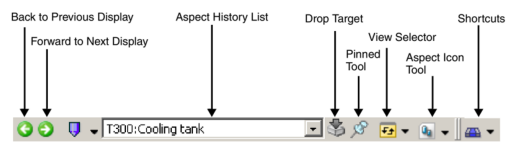

In [9]:
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# Base64 string (trim "data:image/png;base64," if needed)
base64_string = "..."
# Decode the Base64 string
image_data = base64.b64decode(base64_string)

# Convert to an image and display
image = Image.open(BytesIO(image_data))

# Display the image inline
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()